# Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

# Load Dataset

In [ ]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/SwiftCart E-Commerce/Train.csv.xlsx'

df = pd.read_excel(file_path)

print("Dataset berhasil dimuat!")
display(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset berhasil dimuat!


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


# Data Understanding

In [ ]:
print(f"Dimensi Dataset: {df.shape[0]} Baris, {df.shape[1]} Kolom\n")
print("Informasi Dataset:")
df.info()

Dimensi Dataset: 10999 Baris, 12 Kolom

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


# Data Quality Check & Missing Value Analysis

In [ ]:
print("Ringkasan Statistik (Numerik):")
display(df.describe())

print("\nJumlah Missing Value per Kolom:")
display(df.isnull().sum())

Ringkasan Statistik (Numerik):


,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,5500.00000,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691
std,3175.28214,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584
min,1.00000,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,2750.50000,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000
50%,5500.00000,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000
75%,8249.50000,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000
max,10999.00000,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000



Jumlah Missing Value per Kolom:


,0
ID,0
Warehouse_block,0
Mode_of_Shipment,0
Customer_care_calls,0
Customer_rating,0
Cost_of_the_Product,0
Prior_purchases,0
Product_importance,0
Gender,0
Discount_offered,0


# Duplicate Analysis

In [ ]:
duplicate_count = df.duplicated().sum()
print(f"Jumlah baris duplikat identik: {duplicate_count}")

id_duplicate = df.duplicated(subset=['ID']).sum()
print(f"Jumlah ID duplikat: {id_duplicate}")

Jumlah baris duplikat identik: 0
Jumlah ID duplikat: 0


# Data Type Validation & Data Cleaning

In [ ]:
df = df.rename(columns={'Reached.on.Time_Y.N': 'Delivery_Status_ID'})

df['Delivery_Status'] = df['Delivery_Status_ID'].map({1: 'Late', 0: 'On Time'})

print("Data Cleaning Selesai. Tampilan kolom baru:")
display(df[['Delivery_Status_ID', 'Delivery_Status']].head())

Data Cleaning Selesai. Tampilan kolom baru:


,Delivery_Status_ID,Delivery_Status
0,1,Late
1,1,Late
2,1,Late
3,1,Late
4,1,Late


# Outlier Analysis

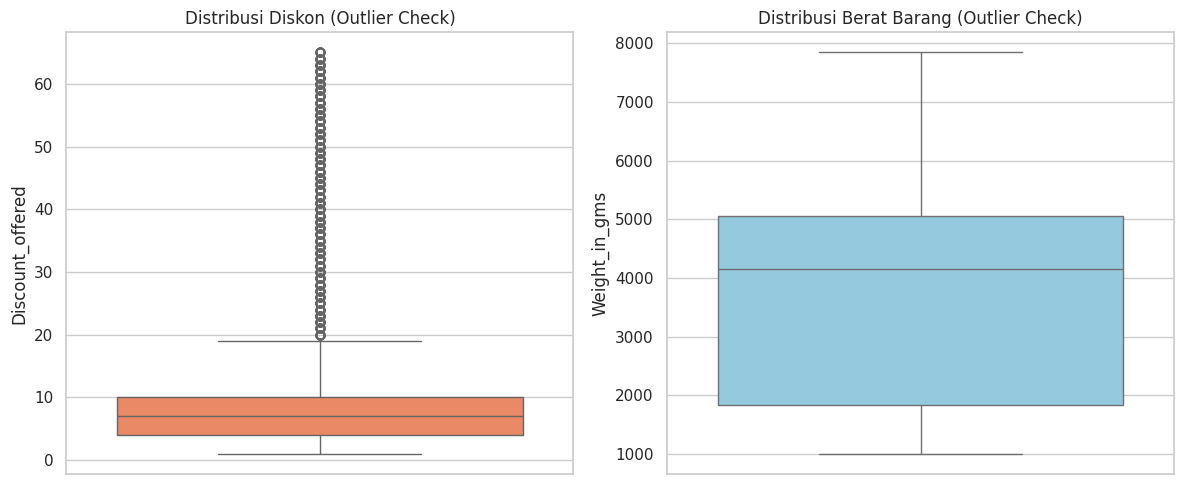

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['Discount_offered'], color='coral')
plt.title('Distribusi Diskon (Outlier Check)')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Weight_in_gms'], color='skyblue')
plt.title('Distribusi Berat Barang (Outlier Check)')

plt.tight_layout()
plt.show()

# Exploratory Data Analysis (EDA)

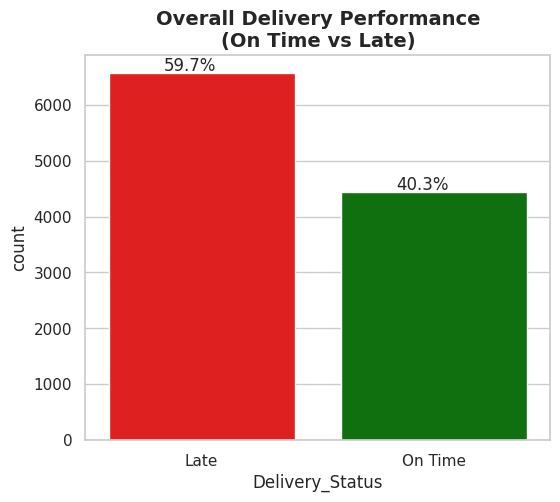

In [ ]:
plt.figure(figsize=(6, 5))
ax = sns.countplot(x='Delivery_Status', data=df, palette={'Late': 'red', 'On Time': 'green'})

total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_y() + p.get_height() + 50
    ax.annotate(percentage, (x, y), ha='center')

plt.title('Overall Delivery Performance\n(On Time vs Late)', fontsize=14, fontweight='bold')
plt.show()

In [ ]:
# Business Insight Analysis

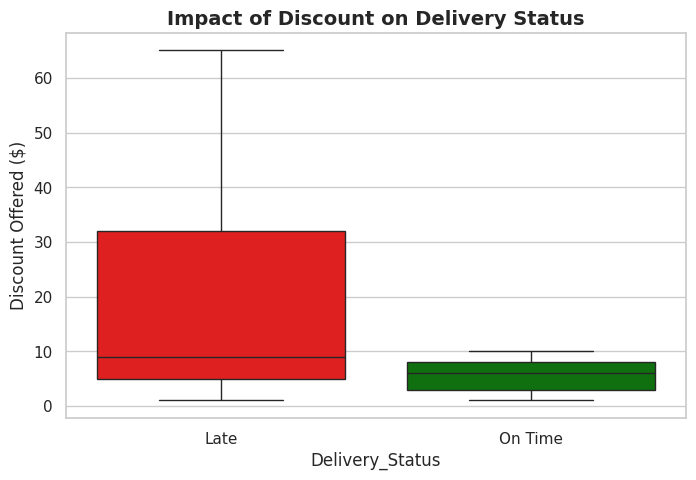

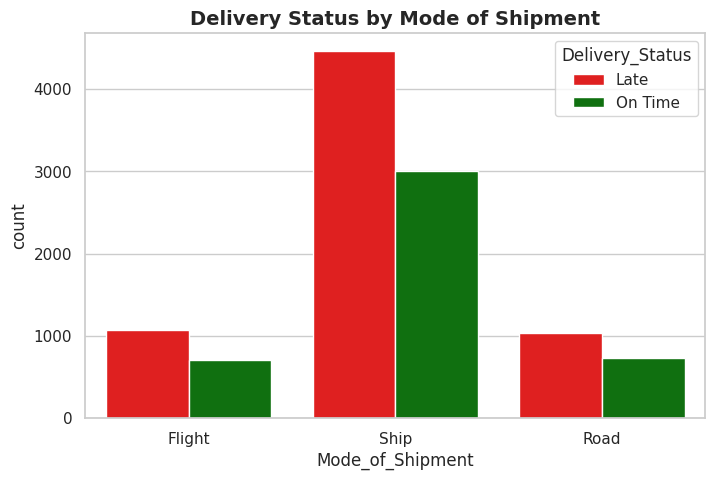

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Delivery_Status', y='Discount_offered', data=df, palette={'Late': 'red', 'On Time': 'green'})
plt.title('Impact of Discount on Delivery Status', fontsize=14, fontweight='bold')
plt.ylabel('Discount Offered ($)')
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Mode_of_Shipment', hue='Delivery_Status', palette={'Late': 'red', 'On Time': 'green'})
plt.title('Delivery Status by Mode of Shipment', fontsize=14, fontweight='bold')
plt.show()

# Feature Engineering

In [ ]:
df['Weight_Category'] = pd.cut(df['Weight_in_gms'],
                               bins=[0, 2000, 4000, 8000],
                               labels=['Light (<2kg)', 'Medium (2-4kg)', 'Heavy (>4kg)'],
                               include_lowest=True)

df['Discount_Category'] = pd.cut(df['Discount_offered'],
                                 bins=[0, 10, 30, 100],
                                 labels=['Low (<$10)', 'Medium ($10-$30)', 'High (>$30)'],
                                 include_lowest=True)

display(df[['Weight_in_gms', 'Weight_Category', 'Discount_offered', 'Discount_Category']].head())

,Weight_in_gms,Weight_Category,Discount_offered,Discount_Category
0,1233,Light (<2kg),44,High (>$30)
1,3088,Medium (2-4kg),59,High (>$30)
2,3374,Medium (2-4kg),48,High (>$30)
3,1177,Light (<2kg),10,Low (<$10)
4,2484,Medium (2-4kg),46,High (>$30)


# Export Clean Dataset

In [ ]:
export_path = '/content/drive/MyDrive/SwiftCart E-Commerce/Clean_SwiftCart_Shipping.csv'

df.to_csv(export_path, index=False)

print(f"Dataset BERHASIL dibersihkan dan DISIMPAN di Google Drive pada lokasi:\n{export_path}")

Dataset BERHASIL dibersihkan dan DISIMPAN di Google Drive pada lokasi:
/content/drive/MyDrive/SwiftCart E-Commerce/Clean_SwiftCart_Shipping.csv


# Final

In [ ]:
late_rate = (df['Delivery_Status'] == 'Late').mean() * 100
avg_discount_late = df[df['Delivery_Status'] == 'Late']['Discount_offered'].mean()
avg_discount_ontime = df[df['Delivery_Status'] == 'On Time']['Discount_offered'].mean()

print("================ FINAL INSIGHT SUMMARY ================")
print(f"1. Tingkat Keterlambatan Global : {late_rate:.1f}%")
print(f"2. Rata-rata diskon barang TERLAMBAT : ${avg_discount_late:.1f}")
print(f"3. Rata-rata diskon barang TEPAT WAKTU : ${avg_discount_ontime:.1f}")
print("=======================================================")
print("\nKESIMPULAN BISNIS SEMENTARA:")
print("Tingkat keterlambatan berada di ambang krisis. Analisis awal menunjukkan")
print("korelasi kuat antara pemberian diskon besar dengan kegagalan operasional logistik.")

================ FINAL INSIGHT SUMMARY ================
1. Tingkat Keterlambatan Global : 59.7%
2. Rata-rata diskon barang TERLAMBAT : $18.7
3. Rata-rata diskon barang TEPAT WAKTU : $5.5

KESIMPULAN BISNIS SEMENTARA:
Tingkat keterlambatan berada di ambang krisis. Analisis awal menunjukkan
korelasi kuat antara pemberian diskon besar dengan kegagalan operasional logistik.
